Available datasets:
 - FinalMasks
 - RAW_Cubes
 - SNV_Cubes
 - wavelength

Dataset loaded successfully

DATASET STRUCTURE
Number of samples      : 39
Spatial dimensions     : 370 × 520
Spectral bands         : 224

Dataset arrays:
RAW_Cubes              : (39, 370, 520, 224)
FinalMasks             : (39, 370, 520)

Selected samples:
[33 36  4 13 30]

Image index: 33
Ignore pixels: 25422


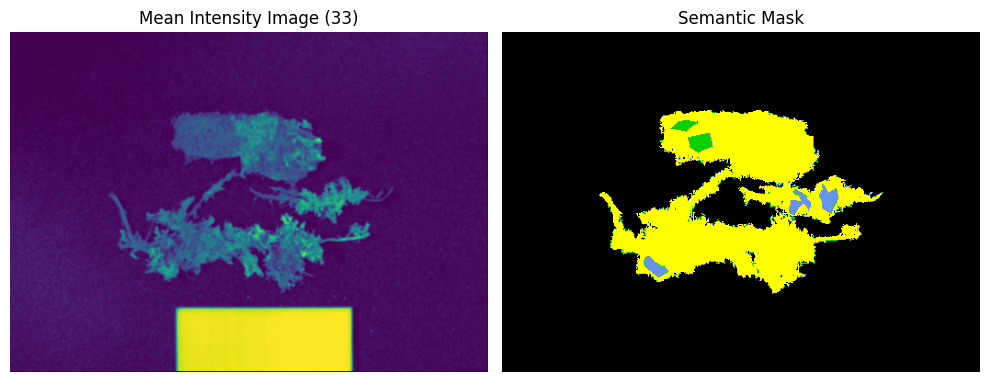


Image index: 36
Ignore pixels: 2445


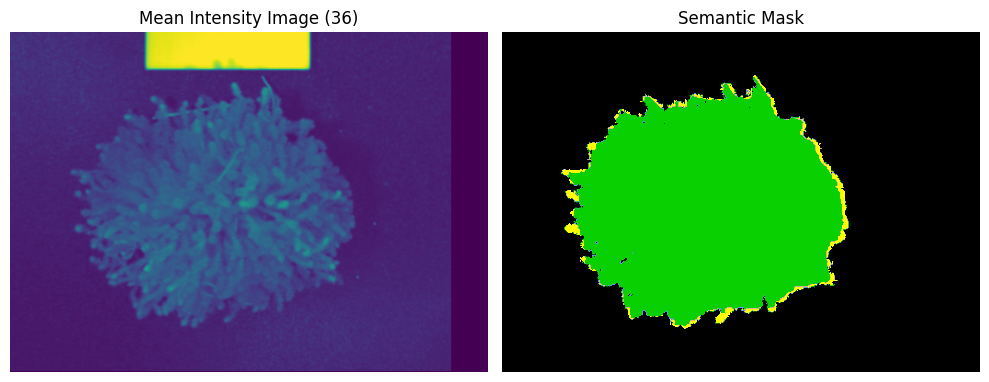


Image index: 4
Ignore pixels: 3198


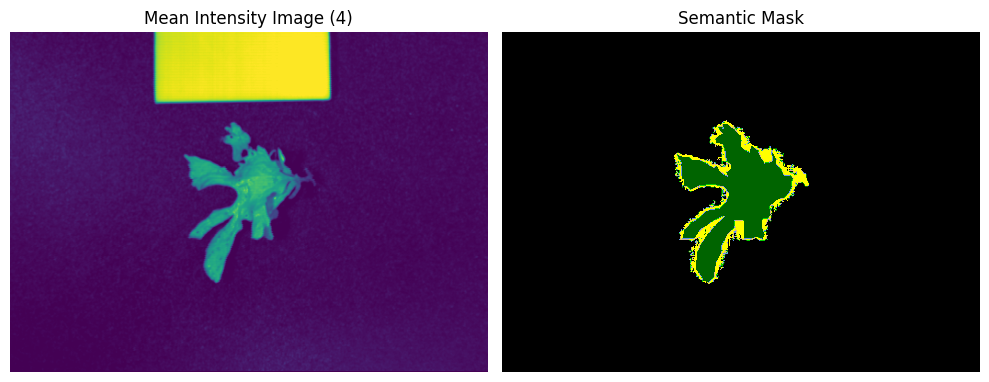


Image index: 13
Ignore pixels: 33094


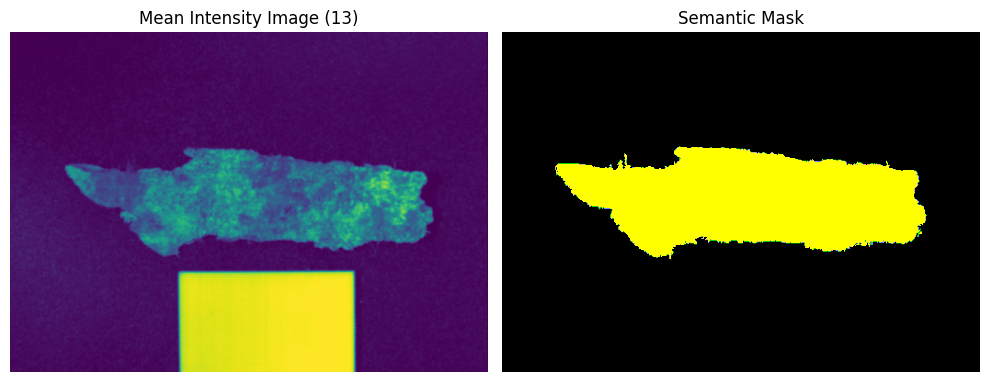


Image index: 30
Ignore pixels: 29714


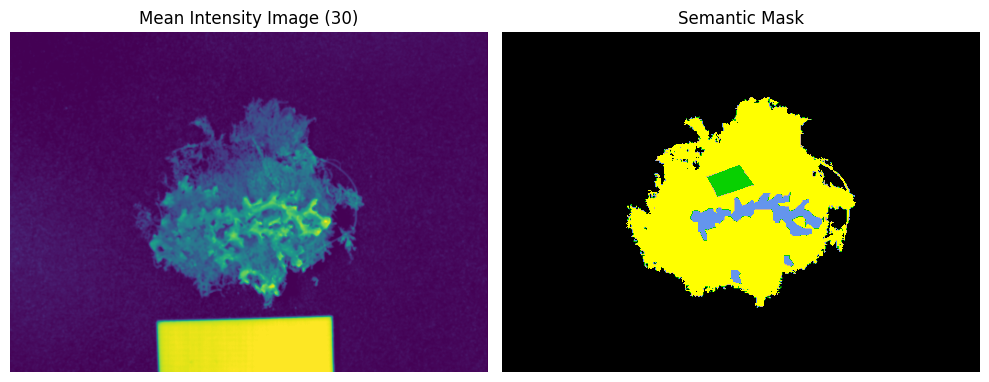


GLOBAL PIXEL DISTRIBUTION
Class   0 (Background          )    6,270,153 pixels ( 83.56%)
Class   1 (Chlorolichen        )      178,452 pixels (  2.38%)
Class   2 (Cyanolichen         )       32,652 pixels (  0.44%)
Class   3 (Bryophyte           )       85,351 pixels (  1.14%)
Class   4 (Bark                )      112,587 pixels (  1.50%)
Class 255 (Unknown / Unlabelled)      824,405 pixels ( 10.99%)

Total pixels: 7503600

ANNOTATION SUMMARY
Annotated images   : 29
Unannotated images : 10

SAMPLE IDENTIFICATION

Annotated sample IDs:
[0, 1, 2, 3, 4, 5, 9, 10, 11, 12, 17, 18, 19, 22, 23, 24, 25, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38]

Unannotated sample IDs:
[6, 7, 8, 13, 14, 15, 16, 20, 21, 26]

CLASS OCCURRENCE
  0 Background           39/39 images
  1 Chlorolichen         15/39 images
  2 Cyanolichen          13/39 images
  3 Bryophyte            14/39 images
  4 Bark                 5/39 images
255 Unknown / Unlabelled 39/39 images

BIOLOGICAL CLASS PIXELS
Chlorolichen   

In [10]:
# ============================================================
# Cryptogams NIR-HSI Dataset Demonstration
#
# This notebook demonstrates:
#   1. Loading the HDF5 dataset
#   2. Inspecting dataset structure
#   3. Visualising hyperspectral samples and semantic masks
#   4. Computing dataset statistics
#   5. Analysing class distribution
#
# Dataset:
# Cryptogams_NIR_HSI_Dataset.h5
#
# HDF5 contents:
#   RAW_Cubes    : Raw hyperspectral cubes
#   SNV_Cubes    : SNV-normalised hyperspectral cubes
#   FinalMasks   : Pixel-level semantic masks
#   wavelength   : Spectral wavelength vector
#
# ============================================================


# ============================================================
# 1. Import Libraries
# ============================================================

import h5py
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap



# ============================================================
# 2. Dataset Path
# ============================================================

# Update H5_PATH to the location where you downloaded
# 'Cryptogams_NIR_HSI_Dataset.h5' on your computer.

H5_PATH = r"/path/to/Cryptogams_NIR_HSI_Dataset.h5"



# ============================================================
# 3. Load HDF5 Dataset
# ============================================================

with h5py.File(H5_PATH, "r") as f:

    print("Available datasets:")
    
    for key in f.keys():
        print(" -", key)


    # Load hyperspectral data
    raw_cubes = f["RAW_Cubes"][:]

    # Load semantic masks
    final_masks = f["FinalMasks"][:]


print("\nDataset loaded successfully")



# ============================================================
# 4. Inspect Dataset Structure
# ============================================================

print("\n" + "="*70)
print("DATASET STRUCTURE")
print("="*70)

print(f"Number of samples      : {raw_cubes.shape[0]}")
print(f"Spatial dimensions     : {raw_cubes.shape[1]} × {raw_cubes.shape[2]}")
print(f"Spectral bands         : {raw_cubes.shape[3]}")

print("\nDataset arrays:")
print(f"RAW_Cubes              : {raw_cubes.shape}")
print(f"FinalMasks             : {final_masks.shape}")



# ============================================================
# 5. Class Definition
# ============================================================

CLASS_LABELS = {

    0:   "Background",
    1:   "Chlorolichen",
    2:   "Cyanolichen",
    3:   "Bryophyte",
    4:   "Bark",
    255: "Unknown / Unlabelled"

}


# Biological classes
ANNOTATED_CLASSES = {1, 2, 3, 4}



# ============================================================
# 6. Visualisation of Random Samples
# ============================================================

# Select five random samples

np.random.seed(42)

sample_indices = np.random.choice(
    raw_cubes.shape[0],
    size=5,
    replace=False
)


print("\nSelected samples:")
print(sample_indices)



# ------------------------------------------------------------
# Semantic mask colour map
# ------------------------------------------------------------

mask_cmap = ListedColormap([

    "#000000",  # Background
    "#006400",  # Chlorolichen
    "#6495ED",  # Cyanolichen
    "#08d001",  # Bryophyte
    "#D2B48C",  # Bark
    "#FFFF00"   # Ignore / Unlabelled

])



# ------------------------------------------------------------
# Display samples
# ------------------------------------------------------------

for idx in sample_indices:


    cube = raw_cubes[idx]

    mask = final_masks[idx]


    # Mean intensity projection across spectral bands

    mean_image = np.mean(
        cube,
        axis=2
    )


    # Contrast enhancement

    p2, p98 = np.percentile(
        mean_image,
        (2,98)
    )

    mean_image = np.clip(
        (mean_image-p2) /
        (p98-p2+1e-8),
        0,
        1
    )


    # Convert ignore label 255 only for visualisation

    display_mask = mask.copy()

    display_mask[display_mask == 255] = 5



    print("\nImage index:", idx)

    print(
        "Ignore pixels:",
        np.sum(mask == 255)
    )



    fig, axes = plt.subplots(
        1,
        2,
        figsize=(10,5)
    )


    # Mean intensity image

    axes[0].imshow(
        mean_image,
        cmap="viridis"
    )

    axes[0].set_title(
        f"Mean Intensity Image ({idx})"
    )

    axes[0].axis("off")



    # Semantic mask

    axes[1].imshow(
        display_mask,
        cmap=mask_cmap,
        vmin=0,
        vmax=5
    )

    axes[1].set_title(
        "Semantic Mask"
    )

    axes[1].axis("off")


    plt.tight_layout()

    plt.show()



# ============================================================
# 7. Global Pixel Distribution
# ============================================================

unique_labels, pixel_counts = np.unique(
    final_masks,
    return_counts=True
)


total_pixels = final_masks.size


print("\n" + "="*70)
print("GLOBAL PIXEL DISTRIBUTION")
print("="*70)



for label, count in zip(unique_labels, pixel_counts):

    percentage = (
        count /
        total_pixels *
        100
    )


    print(
        f"Class {label:3d} "
        f"({CLASS_LABELS[label]:20s}) "
        f"{count:12,} pixels "
        f"({percentage:6.2f}%)"
    )


print("\nTotal pixels:", total_pixels)



# ============================================================
# 8. Annotation Summary
# ============================================================

annotated_images = []

unannotated_images = []


for i, mask in enumerate(final_masks):


    present_classes = set(
        np.unique(mask)
    )


    if present_classes.intersection(
        ANNOTATED_CLASSES
    ):

        annotated_images.append(i)

    else:

        unannotated_images.append(i)



print("\n" + "="*70)
print("ANNOTATION SUMMARY")
print("="*70)


print(
    f"Annotated images   : {len(annotated_images)}"
)


print(
    f"Unannotated images : {len(unannotated_images)}"
)

# ============================================================
# 8.1 Annotated and Unannotated Sample IDs
# ============================================================

print("\n" + "="*70)
print("SAMPLE IDENTIFICATION")
print("="*70)


print("\nAnnotated sample IDs:")
print(annotated_images)


print("\nUnannotated sample IDs:")
print(unannotated_images)

# ============================================================
# 9. Class Occurrence Across Images
# ============================================================

print("\n" + "="*70)
print("CLASS OCCURRENCE")
print("="*70)


for label, name in CLASS_LABELS.items():

    count = 0


    for mask in final_masks:

        if label in np.unique(mask):

            count += 1


    print(
        f"{label:3d} "
        f"{name:20s} "
        f"{count}/{len(final_masks)} images"
    )



# ============================================================
# 10. Pixel Count of Biological Classes
# ============================================================

print("\n" + "="*70)
print("BIOLOGICAL CLASS PIXELS")
print("="*70)


for cls in ANNOTATED_CLASSES:


    total = np.sum(
        final_masks == cls
    )


    print(
        f"{CLASS_LABELS[cls]:20s}: "
        f"{total:,} pixels"
    )



print("\nNotebook completed successfully.")